In [ ]:
from industria.data import load_raw

df = load_raw()
df.shape

(10000, 14)

In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
sensores = ['Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]']

In [ ]:
df[sensores].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


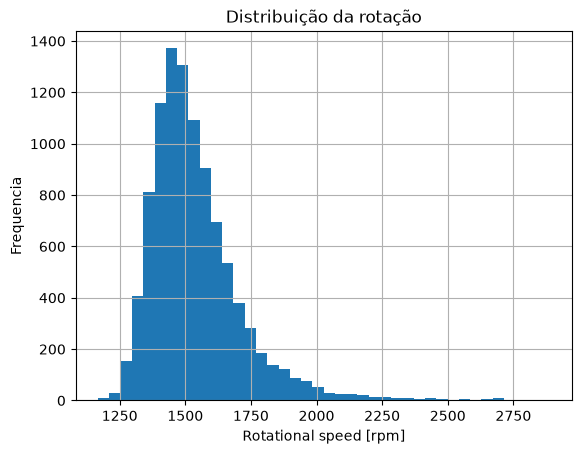

In [ ]:
import matplotlib.pyplot as plt

df["Rotational speed [rpm]"].hist(bins=40)
plt.title("Distribuição da rotação")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Frequencia")
plt.show()

In [ ]:
df.groupby("Machine failure")[sensores].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [ ]:
torque_falhou = df[df["Machine failure"] == 1]["Torque [Nm]"]
torque_ok = df[df["Machine failure"] == 0]["Torque [Nm]"]

print("Falhou:", len(torque_falhou), "| Não falhou:", len(torque_ok))

Falhou: 339 | Não falhou: 9661


In [ ]:
from scipy import stats

t_stat, p_valor = stats.ttest_ind(torque_falhou, torque_ok, equal_var=False)
print("Estatistica t:", t_stat )
print("p-valor:", p_valor)

Estatistica t: 11.780812727929135
p-valor: 3.6357389174388285e-27


In [ ]:
toolf = df[df["Machine failure"] == 1]["Tool wear [min]"]
toolv = df[df["Machine failure"] == 0]["Tool wear [min]"]

print("Falhou:", len(toolf), "| Não falhou:", len(toolv))

Falhou: 339 | Não falhou: 9661


In [ ]:
from scipy import stats

t_stat, p_valor = stats.ttest_ind(toolf, toolv, equal_var=False)
print("Estatistica t:", t_stat )
print("p-valor:", p_valor)

Estatistica t: 9.264289693324807
p-valor: 1.9060112190725033e-18


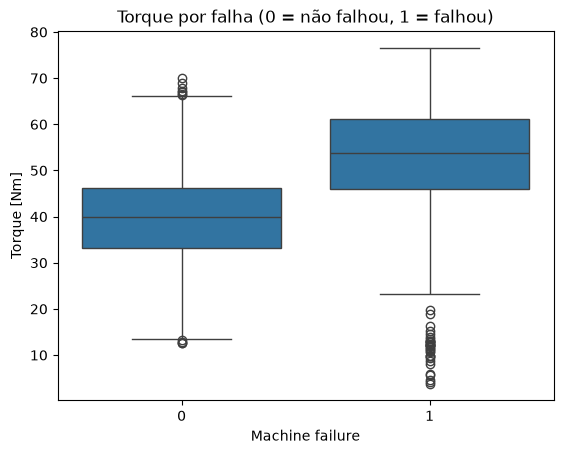

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x="Machine failure", y="Torque [Nm]")
plt.title("Torque por falha (0 = não falhou, 1 = falhou)")
plt.show()

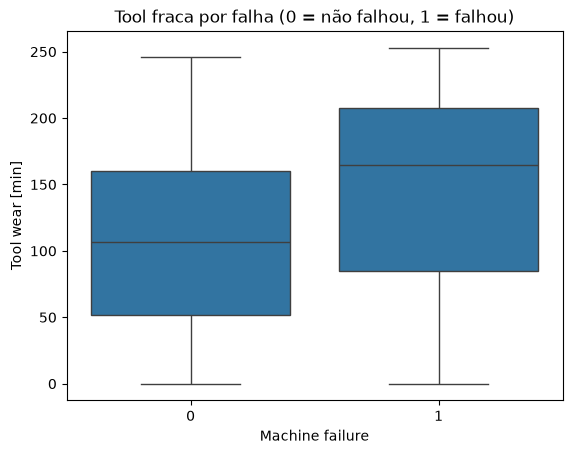

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]")
plt.title("Tool fraca por falha (0 = não falhou, 1 = falhou)")
plt.show()

In [ ]:
df["power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df[["Torque [Nm]", "Rotational speed [rpm]", "power"]].head()

,Torque [Nm],Rotational speed [rpm],power
0,42.8,1551,66382.8
1,46.3,1408,65190.4
2,49.4,1498,74001.2
3,39.5,1433,56603.5
4,40.0,1408,56320.0


In [ ]:
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df[["Process temperature [K]", "Air temperature [K]", "temp_diff"]].head()

,Process temperature [K],Air temperature [K],temp_diff
0,308.6,298.1,10.5
1,308.7,298.2,10.5
2,308.5,298.1,10.4
3,308.6,298.2,10.4
4,308.7,298.2,10.5


In [ ]:

df["strain"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df[["Tool wear [min]", "Torque [Nm]","strain"]].head()

,Tool wear [min],Torque [Nm],strain
0,0,42.8,0.0
1,3,46.3,138.9
2,5,49.4,247.0
3,7,39.5,276.5
4,9,40.0,360.0


In [ ]:
from industria.features import add_features

df_feat = add_features(load_raw())
df_feat[["power", "temp_diff", "strain"]].head()

NameError: name 'load_raw' is not defined